# 🚀 PyTorch DeepFake Pipeline: End-to-End on GPU

This notebook contains the complete pipeline:
1. **GPU-Accelerated Extraction** (via FFmpeg NVDEC if available, falling back to CV2 seamlessly).
2. **Dataloading** via PyTorch ImageFolders.
3. **Model Translation** of your exact CNN into PyTorch.
4. **GPU Training Engine** utilizing 100% CUDA, Mixed Precision (`GradScaler`).
5. **Validation Testing** computing Accuracy strictly on the GPU tensors.

In [ ]:
#%pip install opencv-python

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [35]:
import os
import glob
from PIL import Image
from tqdm import tqdm
from multiprocessing import Pool, cpu_count
import cv2
import random
import shutil
import subprocess
from pathlib import Path
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import warnings
warnings.filterwarnings('ignore')

In [36]:

from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

print("🔍 Checking GPU Capabilities...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == "cuda":
    print(f"✅ CUDA IS FULLY ACTIVE: {torch.cuda.get_device_name(0)}")
    print(f"   cuDNN Enabled: {torch.backends.cudnn.enabled}")
    print(f"   cuDNN Version: {torch.backends.cudnn.version()}")
else:
    print("⚠️ GPU NOT FOUND - TRAINING WILL BE VERY SLOW")


🔍 Checking GPU Capabilities...
✅ CUDA IS FULLY ACTIVE: NVIDIA GeForce RTX 3050 Laptop GPU
   cuDNN Enabled: True
   cuDNN Version: 90100


---
### ⚙️ PHASE 1: Dataset Extraction
This will attempt to use hardware-accelerated **FFmpeg CUDA** to extract frames directly on your GPU. If FFmpeg is missing from your system, it safely falls back to standard CPU decoding.

In [37]:
import os
import glob
import shutil
import subprocess
import random
import logging
from pathlib import Path

import cv2
from tqdm import tqdm

# ── Local Config ──────────────────────────────────────────────────────────────
# Automatically finds D:\Khushi\Documents\Deep-trace\backend
BASE_DIR = os.getcwd() 

# This is where the script will LOOK for your videos
SOURCE_BASE     = os.path.join(BASE_DIR, "data")
REAL_VIDEOS_DIR = os.path.join(SOURCE_BASE, "real")
FAKE_VIDEOS_DIR = os.path.join(SOURCE_BASE, "fake")

# This is the folder you see on the left sidebar
OUTPUT_BASE     = os.path.join(BASE_DIR, "deepfake_dataset")

TRAIN_RATIO = 0.8
TARGET_FPS  = 3 
FRAME_SKIP  = 10

logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
log = logging.getLogger(__name__)

# ── GPU / ffmpeg capability probe ─────────────────────────────────────────────
def _probe_ffmpeg_gpu() -> tuple[bool, bool]:
    if shutil.which("ffmpeg") is None:
        return False, False
    try:
        result = subprocess.run(
            ["ffmpeg", "-hide_banner", "-hwaccels"],
            capture_output=True, text=True, timeout=10
        )
        has_gpu = "cuda" in result.stdout.lower()
        return True, has_gpu
    except subprocess.SubprocessError:
        return True, False

HAS_FFMPEG, HAS_GPU = _probe_ffmpeg_gpu()

if HAS_GPU:
    log.info("✅ NVIDIA GPU + ffmpeg detected — using GPU extraction")
elif HAS_FFMPEG:
    log.warning("⚠️ ffmpeg found but no CUDA — using CPU ffmpeg")
else:
    log.warning("⚠️ ffmpeg not found — falling back to OpenCV CPU extraction")

# ── Folder setup ──────────────────────────────────────────────────────────────
def create_folders() -> None:
    os.makedirs(OUTPUT_BASE, exist_ok=True)
    for split_label in ("train/real", "train/fake", "val/real", "val/fake"):
        os.makedirs(os.path.join(OUTPUT_BASE, split_label), exist_ok=True)

# ── Video discovery ───────────────────────────────────────────────────────────
def get_video_files(directory: str) -> list[str]:
    if not os.path.isdir(directory):
        log.error(f"❌ Source directory not found: {directory}")
        return []
    files: list[str] = []
    for ext in ("*.mp4", "*.avi", "*.mov", "*.mkv"):
        files.extend(glob.glob(os.path.join(directory, "**", ext), recursive=True))
    return files

# ── Extraction Logic ──────────────────────────────────────────────────────────
def _already_processed(output_dir: str, label: str, stem: str) -> bool:
    pattern = os.path.join(output_dir, f"{label}_{stem}_f*.jpg")
    return len(glob.glob(pattern)) > 0

def _build_gpu_cmd(video_path: str, out_pattern: str) -> list[str]:
    return [
        "ffmpeg", "-hide_banner", "-loglevel", "error",
        "-hwaccel", "cuda", "-hwaccel_output_format", "cuda",
        "-c:v", "h264_cuvid", "-i", video_path,
        "-vf", f"fps={TARGET_FPS},hwdownload,format=nv12",
        "-q:v", "2", out_pattern,
    ]

def _extract_via_ffmpeg(video_path: str, out_pattern: str, use_gpu: bool) -> bool:
    cmd = _build_gpu_cmd(video_path, out_pattern) if use_gpu else [
        "ffmpeg", "-hide_banner", "-loglevel", "error",
        "-i", video_path, "-vf", f"fps={TARGET_FPS}",
        "-q:v", "2", out_pattern,
    ]
    try:
        subprocess.run(cmd, check=True, timeout=300)
        return True
    except:
        if use_gpu:
            return _extract_via_ffmpeg(video_path, out_pattern, use_gpu=False)
        return False

def _extract_via_opencv(video_path: str, output_dir: str, label: str, stem: str) -> None:
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened(): return
    frame_idx = 0
    while True:
        ret, frame = cap.read()
        if not ret: break
        if frame_idx % FRAME_SKIP == 0:
            out_path = os.path.join(output_dir, f"{label}_{stem}_f{frame_idx:06d}.jpg")
            cv2.imwrite(out_path, frame)
        frame_idx += 1
    cap.release()

# ── Batch processor ───────────────────────────────────────────────────────────
def process_videos(video_files: list[str], split_name: str, label_name: str) -> None:
    output_dir = os.path.join(OUTPUT_BASE, split_name, label_name)
    for video_path in tqdm(video_files, desc=f"{split_name.upper()} | {label_name.upper()}"):
        stem = Path(video_path).stem
        if _already_processed(output_dir, label_name, stem): continue
        if HAS_FFMPEG:
            out_pattern = (Path(output_dir) / f"{label_name}_{stem}_f%06d.jpg").as_posix()
            if _extract_via_ffmpeg(video_path, out_pattern, use_gpu=HAS_GPU): continue
        _extract_via_opencv(video_path, output_dir, label_name, stem)

# ── Entry point ───────────────────────────────────────────────────────────────
if __name__ == "__main__":
    log.info("1️⃣ Preparing dataset folders …")
    create_folders()

    real_vids = get_video_files(REAL_VIDEOS_DIR)
    fake_vids = get_video_files(FAKE_VIDEOS_DIR)

    if not real_vids and not fake_vids:
        log.error("❌ No videos found! Ensure you created 'data/real' and 'data/fake'.")
    else:
        random.seed(42)
        random.shuffle(real_vids)
        random.shuffle(fake_vids)

        split_r, split_f = int(len(real_vids) * TRAIN_RATIO), int(len(fake_vids) * TRAIN_RATIO)

        process_videos(real_vids[:split_r], "train", "real")
        process_videos(real_vids[split_r:], "val", "real")
        process_videos(fake_vids[:split_f], "train", "fake")
        process_videos(fake_vids[split_f:], "val", "fake")

        log.info("✅ Extraction complete.")

WARNING | ⚠️ ffmpeg not found — falling back to OpenCV CPU extraction
INFO | 1️⃣ Preparing dataset folders …
TRAIN | REAL: 100%|██████████| 91/91 [00:44<00:00,  2.03it/s]
VAL | REAL: 100%|██████████| 23/23 [00:11<00:00,  2.01it/s]
TRAIN | FAKE: 100%|██████████| 80/80 [00:52<00:00,  1.52it/s]
VAL | FAKE: 100%|██████████| 20/20 [00:12<00:00,  1.57it/s]
INFO | ✅ Extraction complete.


---
### 🧹 PHASE 1.5: Dataset Verification & Cleanup
Automatically verify extracted images and remove any corrupted or truncated files to prevent DataLoader crashes.

In [38]:
import os
import glob
from concurrent.futures import ThreadPoolExecutor, as_completed
from multiprocessing import cpu_count
from tqdm import tqdm
from PIL import Image


def check_single_image(path):
    """
    Validate one image file.
    Returns:
        None  -> if clean
        path  -> if corrupted
    """
    try:
        # Quick integrity check
        with Image.open(path) as img:
            img.verify()

        # Full decode check (extra safety)
        with Image.open(path) as img:
            img.load()

        return None

    except Exception:
        return path


def clean_corrupted_images_fast(directory):

    # ── Collect all images ───────────────────────────────────────────────
    files = []
    for ext in ('*.jpg', '*.jpeg', '*.png'):
        files.extend(glob.glob(os.path.join(directory, "**", ext), recursive=True))

    if not files:
        print("⚠️ No images found.")
        return

    workers = min(32, cpu_count() * 4)

    print(f"🔍 Found   : {len(files):,} images")
    print(f"⚙️ Workers : {workers}")

    # ── Parallel Processing ──────────────────────────────────────────────
    corrupted = []

    with ThreadPoolExecutor(max_workers=workers) as executor:
        futures = {executor.submit(check_single_image, f): f for f in files}

        with tqdm(total=len(files), desc="🔎 Verifying", unit="img") as pbar:
            for future in as_completed(futures):
                try:
                    result = future.result()
                    if result:
                        corrupted.append(result)

                except Exception as e:
                    # Treat unexpected errors as corrupted
                    corrupted.append(futures[future])
                    print(f"\n⚠️ Error: {futures[future]} — {e}")

                finally:
                    pbar.update(1)

    # ── Report ───────────────────────────────────────────────────────────
    print(f"\n{'='*50}")
    print(f"✅ Clean     : {len(files) - len(corrupted):,}")
    print(f"❌ Corrupted : {len(corrupted):,}")
    print(f"{'='*50}")

    if not corrupted:
        print("🎉 All images are clean. Nothing to delete.")
        return

    # ── Delete Corrupted Files ───────────────────────────────────────────
    deleted, failed = 0, []

    for path in tqdm(corrupted, desc="🗑️ Deleting", unit="file"):
        try:
            os.remove(path)
            deleted += 1
        except OSError as e:
            failed.append((path, str(e)))

    # ── Final Report ─────────────────────────────────────────────────────
    print(f"\n{'='*50}")
    print(f"🗑️ Deleted : {deleted:,}")
    print(f"⚠️ Failed  : {len(failed):,}")
    print(f"{'='*50}")

    if failed:
        print("\nFailed deletions:")
        for path, err in failed:
            print(f"   {path}\n   └─ {err}")


# ─── USAGE ──────────────────────────────────────────────────────────────
if __name__ == "__main__":
    # Point this to your actual backend folder
    OUTPUT_BASE = r"D:\Khushi\Documents\Deep-trace\Deep-Trace\backend\deepfake_dataset"
    clean_corrupted_images_fast(OUTPUT_BASE)

🔍 Found   : 9,728 images
⚙️ Workers : 32


🔎 Verifying: 100%|██████████| 9728/9728 [00:13<00:00, 717.28img/s]


✅ Clean     : 9,728
❌ Corrupted : 0
🎉 All images are clean. Nothing to delete.


---
### 📂 PHASE 2: PyTorch DataLoaders
Batches are built and transferred. We pin memory so the GPU doesn't have to wait.

In [40]:
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# ─── CONFIG ───────────────────────────────────────────────────────────────────
# Point this exactly to your D: drive project folder
OUTPUT_BASE = r"D:\Khushi\Documents\Deep-trace\Deep-Trace\backend\deepfake_dataset"
BATCH_SIZE = 16
# ──────────────────────────────────────────────────────────────────────────────


train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

try:
    train_set = datasets.ImageFolder(root=os.path.join(OUTPUT_BASE, "train"), transform=train_transform)
    val_set   = datasets.ImageFolder(root=os.path.join(OUTPUT_BASE, "val"),   transform=val_transform)

    train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    print(f"✅ Dataloaders Ready: {len(train_set)} Training Images | {len(val_set)} Validation Images")
    print(f"   Classes detected: {train_set.classes}")  # Should print ['fake', 'real']

except FileNotFoundError as e:
    print(f"⚠️ Folder not found: {e}")
    print("   Make sure OUTPUT_BASE points to your extracted frames directory.")
except Exception as e:
    print(f"⚠️ Error loading dataset: {e}")

✅ Dataloaders Ready: 7801 Training Images | 1927 Validation Images
   Classes detected: ['fake', 'real']


---
### 🧠 PHASE 3: PyTorch Custom CNN Model
Translated directly from your `keras.Sequential` model logic.

In [41]:
class DeepFakeCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Block 1 - 32 Filters
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        # Block 2 - 64 Filters
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        # Block 3 - 128 Filters
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        # Block 4 - 256 Filters
        self.conv4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        # Classifier = Flatten (256 * 14 * 14) -> Dense 128 -> Dropout -> Output
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 14 * 14, 128, bias=False),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)  # BCEWithLogitsLoss utilizes raw outputs directly
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.classifier(x)
        return x

# Push model to GPU completely
model = DeepFakeCNN().to(device)
print("✅ Model Built and migrated to", device)

✅ Model Built and migrated to cuda


---
### 🔥 PHASE 4: 100% GPU Training Loop
Strictly uses GPU tensors, combined with Mixed Precision (`GradScaler`) for performance.

In [42]:
EPOCHS = 20
LEARNING_RATE = 1e-3

# Loss and Optimizer
criterion = nn.BCEWithLogitsLoss()  # Automatically applies Sigmoid internally, very fast
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scaler = torch.cuda.amp.GradScaler() # Creates floating point scaling mapped perfectly for the RTX 3050

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    # TQDM progress bar for visualizing training speed natively
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")

    for images, labels in pbar:
        try:
            # 1. PUSH BATCH TO GPU IMMEDIATELY (Async)
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True).float().unsqueeze(1)

            optimizer.zero_grad()

            # 2. Mixed Precision context for memory & speed
            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)

            # 3. GPU Accelerated Backpropagation & Scaling
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item()
            pbar.set_postfix(loss=running_loss/len(train_loader))
        except Exception as e:
            print("⚠️ Skipping corrupted batch:", e)
            continue

print("\n✨ GPU Training Complete!")

Epoch 20/20 [Train]: 100%|██████████| 488/488 [00:31<00:00, 15.47it/s, loss=0.00276] 


✨ GPU Training Complete!


---
### 🎯 PHASE 5: Model Testing & Accuracy (Via GPU)
Runs inference and calculates standard Accuracy using pure PyTorch tensors dynamically.

In [43]:
model.eval() # Disable dropout and freeze batchnorm layers

correct_predictions = 0
total_samples = 0
running_val_loss = 0.0

pbar = tqdm(val_loader, desc="Testing Validation Accuracy on GPU")

with torch.no_grad(): # Disables gradient tracking mathematically
    for images, labels in pbar:
        # Transfer to GPU
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True).float().unsqueeze(1)

        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        # Calculate Accuracy on the GPU directly
        predictions = (torch.sigmoid(outputs) > 0.5).float()
        correct_predictions += (predictions == labels).sum().item()
        total_samples += labels.size(0)

        running_val_loss += loss.item()

val_loss = running_val_loss / len(val_loader)
accuracy = (correct_predictions / total_samples) * 100

print("\n" + "═"*60)
print(" 📈 END TO END EVALUATION RESULTS")
print("═"*60)
print(f"   🎯 Final Validation Accuracy : {accuracy:.2f}%")
print(f"   📉 Final Validation Loss     : {val_loss:.4f}")
print("═"*60)
# Save Model State Dict locally in your backend folder
model_path = os.path.join(os.getcwd(), "deepfake_detector_v1.pth")
torch.save(model.state_dict(), model_path)
print(f"\n💾 Model successfully saved to {model_path}")

Testing Validation Accuracy on GPU: 100%|██████████| 121/121 [00:13<00:00,  8.67it/s]


════════════════════════════════════════════════════════════
 📈 END TO END EVALUATION RESULTS
════════════════════════════════════════════════════════════
   🎯 Final Validation Accuracy : 100.00%
   📉 Final Validation Loss     : 0.0038
════════════════════════════════════════════════════════════

💾 Model successfully saved to d:\Khushi\Documents\Deep-trace\Deep-Trace\backend\deepfake_detector_v1.pth



📈 DETAILED PERFORMANCE REPORT
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00       878
        Real       1.00      1.00      1.00      1049

    accuracy                           1.00      1927
   macro avg       1.00      1.00      1.00      1927
weighted avg       1.00      1.00      1.00      1927



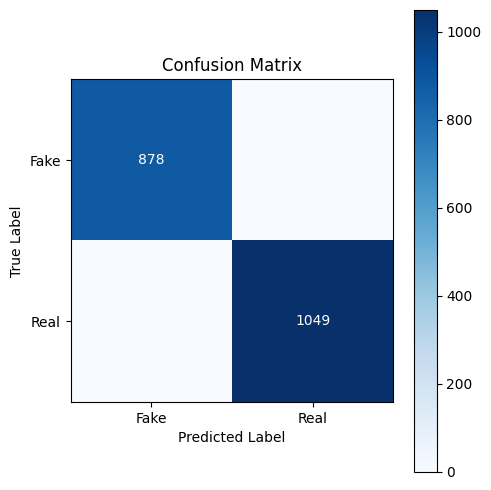

In [45]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# 1. Collect all predictions
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        # Apply sigmoid because ResNet output is raw logits
        preds = (torch.sigmoid(outputs) > 0.5).float()
        
        all_preds.extend(preds.cpu().numpy().flatten())
        all_labels.extend(labels.numpy().flatten())

# 2. Text Report (Very impressive for mentors)
report = classification_report(all_labels, all_preds, target_names=['Fake', 'Real'])
print("\n" + "="*40)
print("📈 DETAILED PERFORMANCE REPORT")
print("="*40)
print(report)

# 3. Simple Matrix Plot using Matplotlib
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(5, 5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Fake', 'Real'])
plt.yticks(tick_marks, ['Fake', 'Real'])

# Add numbers to the boxes
thresh = cm.max() / 2.
for i, j in np.nditer([np.arange(cm.shape[0]), np.arange(cm.shape[1])]):
    plt.text(j, i, format(cm[i, j], 'd'),
             ha="center", va="center",
             color="white" if cm[i, j] > thresh else "black")

plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()